<h1 style="text-align:center;">AF3 Motif Validation TEMPO</h1>

In [33]:
import glob
import os
import shutil
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from Bio.PDB import MMCIFParser
from Bio.SeqUtils import seq1
from scipy.stats import spearmanr
from sklearn.metrics import roc_curve, roc_auc_score

# Reference : SEQTR data from Liu et al.

In [44]:
topdir = 'AF3_motif_validation_TEMPO'
model = 'A0201_LLWNGPMAV'

df = pd.read_csv(f'{topdir}/media-7.csv')
df = df[df['model'] == model]

df.to_csv(f'{topdir}/A0201_LLWNGPMAV_SEQTR.csv', index=False)
print(len(df))

3710


# Top predictions from AF3 Motif Builder

In [45]:
# prepaire csv for motif building
topdir = 'AF3_motif_validation_TEMPO'

steps = {'step2':0.8}
peptides = ['LLWNGPMAV']

for step, threshold in steps.items():
    for peptide in peptides:
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)

        df = pd.merge(df, anno, on='id')
        df.to_csv(f'{topdir}/A0201_LLWNGPMAV_baseline_AF3.csv', index=False)
            
        df = df[df['AF3_iptm_pair_mean'] > threshold]
        df['model'] = f'A0201_{peptide}'
        df.to_csv(f'{topdir}/A0201_LLWNGPMAV_AF3.csv', index=False)
        print(len(df))

167


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_6145/3617403456.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_6145/3617403456.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)


# Validation data 
positives = Public available TCRs from Liu et al. <br>
negatives = repertoire data from Shah et al. <br>

In [ ]:
topdir = 'AF3_motif_validation_TEMPO'
model = 'A0201_LLWNGPMAV'

df1 = pd.read_csv(f'{topdir}/media-3.csv')[['model', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB']]
df1 = df1[df1['model'] == model]
df1 = df1.dropna()
df1['label'] = 1 # positives

df2 = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source']]
df2 = df2.rename(columns={'Epitope' : 'model'})
df2 = df2[df2['model'] == model]
df2 = df2[df2['dataset_source'] == 'Public TCRs with undetermined specificities']

df2['label'] = 0 # negatives
df2 = df2.sample(n=len(df1))

df = pd.concat([df1, df2])
df.to_csv(f'{topdir}/validation.csv')

778


# AUC

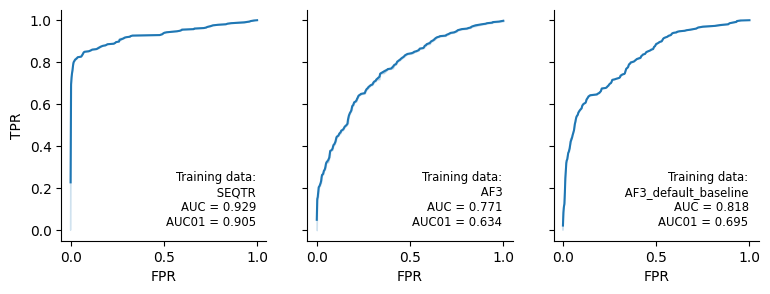

In [43]:
topdir = 'AF3_motif_validation_TEMPO'

batches = ['SEQTR', 'AF3', 'AF3_default_baseline']
#

fig, axes = plt.subplots(1, 3, figsize=(9,3), sharey=True)

for cnt, batch in enumerate(batches):
    ax = axes[cnt]
    
    df = pd.read_csv(f'{topdir}/{batch}/A0201_LLWNGPMAV_pred.csv')
    df = df[df['Problem'].isna()]

    y_scores = df['score'].values
    y_true = df['label'].values


    # ROC + metrics
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_full = roc_auc_score(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # standardized AUC01

    # plot
    sns.lineplot(x=fpr, y=tpr, ax=ax)
    label = f"Training data:\n {batch}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"


    ax.text(0.95, 0.05, label, transform=ax.transAxes, ha='right', va='bottom', fontsize='small')

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    sns.despine()
